# Multimodal QSVM — Dementia Detection (Task D)
Fuses clinical + MRI + speech PCA features into one 6-feature vector per patient and trains a quantum SVM.

**Notes:**
- Uses `FidelityStatevectorKernel` (exact statevector inner products) instead of `FidelityQuantumKernel` — same kernel mathematically, but computes one statevector per sample (225) rather than ~24k pairwise fidelity circuits. Deterministic, runs in seconds.
- Adds a `MinMaxScaler` step before the quantum feature map. PCA outputs span ~[-3.8, 4.6]; fed raw into `ZZFeatureMap` they exceed 2π and alias, collapsing the kernel to near-identity (QSVM then guesses the majority class). Scaling to a bounded range fixes this. Scaler is fit on the train split only and pickled for demo-time prediction.

In [1]:
import numpy as np
import pandas as pd
import json
import pickle
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityStatevectorKernel
from qiskit_machine_learning.algorithms import QSVC
import warnings
warnings.filterwarnings('ignore')
print('✅ All imports successful')

✅ All imports successful


In [2]:
# Load PCA outputs from each modality notebook
try:
    X_clinical = np.load('results/X_clinical_pca.npy')
    print(f'✅ Clinical PCA loaded   — shape: {X_clinical.shape}')
except FileNotFoundError:
    raise FileNotFoundError('❌ Run clinical_qsvm.ipynb first and push X_clinical_pca.npy')

try:
    X_mri = np.load('results/X_mri_pca.npy')
    print(f'✅ MRI PCA loaded        — shape: {X_mri.shape}')
except FileNotFoundError:
    raise FileNotFoundError('❌ Run mri_qsvm.ipynb first and push X_mri_pca.npy')

try:
    X_speech = np.load('results/X_speech_pca.npy')
    print(f'✅ Speech PCA loaded     — shape: {X_speech.shape}')
except FileNotFoundError:
    raise FileNotFoundError('❌ Run speech_qsvm.ipynb first and push X_speech_pca.npy')

y = np.load('results/y_labels.npy')
print(f'✅ Labels loaded         — shape: {y.shape}')
print(f'\nLabel distribution: {np.bincount(y)}  ([Nondemented, Demented])')

✅ Clinical PCA loaded   — shape: (225, 2)
✅ MRI PCA loaded        — shape: (225, 2)
✅ Speech PCA loaded     — shape: (225, 2)
✅ Labels loaded         — shape: (225,)

Label distribution: [124 101]  ([Nondemented, Demented])


In [3]:
# All three arrays must have exactly 225 rows — same order as the CSV
assert X_clinical.shape == (225, 2), f'Clinical shape wrong: {X_clinical.shape}'
assert X_mri.shape      == (225, 2), f'MRI shape wrong: {X_mri.shape}'
assert X_speech.shape   == (225, 2), f'Speech shape wrong: {X_speech.shape}'
assert y.shape          == (225,),   f'Labels shape wrong: {y.shape}'
print('✅ All shape checks passed')

# Concatenate: each patient is now represented by 6 features
# [clinical_pc1, clinical_pc2, mri_pc1, mri_pc2, speech_pc1, speech_pc2]
X_full = np.concatenate([X_clinical, X_mri, X_speech], axis=1)
print(f'\nConcatenated feature matrix: {X_full.shape}')  # (225, 6)
print('Feature layout: [clinical_pc1, clinical_pc2, mri_pc1, mri_pc2, speech_pc1, speech_pc2]')

✅ All shape checks passed

Concatenated feature matrix: (225, 6)
Feature layout: [clinical_pc1, clinical_pc2, mri_pc1, mri_pc2, speech_pc1, speech_pc2]


In [4]:
# One split for all modalities — guaranteed aligned because rows come from same CSV
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train labels: {np.bincount(y_train)}  |  Test labels: {np.bincount(y_test)}')

Train: (180, 6)  |  Test: (45, 6)
Train labels: [99 81]  |  Test labels: [25 20]


In [5]:
# --- Scale features into an angle-friendly range for the quantum feature map ---
# Raw PCA values span ~[-3.8, 4.6]; fed directly into ZZFeatureMap they exceed 2*pi
# and alias, collapsing the fidelity kernel to near-identity (QSVM guesses majority
# class). MinMaxScaler -> [0, 1] keeps rotation angles well-behaved.
# Fit on TRAIN ONLY to avoid leakage; apply the same transform to both models.
scaler = MinMaxScaler(feature_range=(0, 1))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f'Scaled train range: {X_train.min():.3f} → {X_train.max():.3f}')
print(f'Scaled test  range: {X_test.min():.3f} → {X_test.max():.3f}  (may slightly exceed [0,1] — expected)')

Scaled train range: 0.000 → 1.000
Scaled test  range: 0.070 → 1.062  (may slightly exceed [0,1] — expected)


In [6]:
# Classical SVM with RBF kernel on the 6-feature concatenated vector
# This is our internal baseline — what we must beat with QSVM
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_clf.fit(X_train, y_train)
svm_pred = svm_clf.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print('=== Classical SVM — Multimodal (6 features) ===')
print(f'Accuracy: {svm_acc:.4f}  ({svm_acc*100:.2f}%)')
print(classification_report(y_test, svm_pred,
                            target_names=['Nondemented', 'Demented']))

=== Classical SVM — Multimodal (6 features) ===
Accuracy: 1.0000  (100.00%)
              precision    recall  f1-score   support

 Nondemented       1.00      1.00      1.00        25
    Demented       1.00      1.00      1.00        20

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
# ZZFeatureMap with 6 qubits — one per PCA component (2 per modality)
# entanglement='linear': adjacent qubits interact (within- and cross-modality)
# reps=2: encoding layer repeated twice for a richer quantum feature space
#
# FidelityStatevectorKernel: exact, deterministic. Computes one statevector per
# sample then takes |<psi_i|psi_j>|^2 — far cheaper than pairwise fidelity circuits.
feature_map = ZZFeatureMap(feature_dimension=6, reps=2, entanglement='linear')
quantum_kernel = FidelityStatevectorKernel(feature_map=feature_map)

print('Training multimodal QSVM (exact statevector kernel)...')
t0 = time.time()
qsvm_clf = QSVC(quantum_kernel=quantum_kernel)
qsvm_clf.fit(X_train, y_train)

qsvm_pred = qsvm_clf.predict(X_test)
qsvm_acc = accuracy_score(y_test, qsvm_pred)
print(f'Done in {time.time()-t0:.1f}s')

print('\n=== QSVM (ZZFeatureMap, 6 qubits) — Multimodal ===')
print(f'Accuracy: {qsvm_acc:.4f}  ({qsvm_acc*100:.2f}%)')
print(classification_report(y_test, qsvm_pred,
                            target_names=['Nondemented', 'Demented']))

Training multimodal QSVM (exact statevector kernel)...


Done in 3.2s

=== QSVM (ZZFeatureMap, 6 qubits) — Multimodal ===
Accuracy: 1.0000  (100.00%)
              precision    recall  f1-score   support

 Nondemented       1.00      1.00      1.00        25
    Demented       1.00      1.00      1.00        20

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [8]:
print('\n' + '='*65)
print(f'{"PHASE 1 COMPLETE RESULTS":^65}')
print('='*65)
print(f'{"Model":<40} {"Accuracy":>10}  {"Source":>8}')
print('-'*65)

rows = [
    ('Classical SVM — Multimodal (ours)',     svm_acc*100,  'Ours'),
    ('QSVM ZZFeatureMap — Multimodal (ours)', qsvm_acc*100, 'Ours ★'),
    ('-'*40,                                   None,         ''),
    ('So et al. (Clinical only)',              97.20,        'REF-7'),
    ('Lin & Washington (Speech only)',         84.00,        'REF-6'),
    ('Akinrotimi QSVM (BASE)',                 91.25,        'BASE ◄'),
    ('Chakravarthi Classical Multimodal',      94.20,        'REF-1 ◄'),
]

for name, acc, source in rows:
    if acc is None:
        print(f'{name}')
    else:
        beat = ' ✅ BEAT' if (acc > 91.25 and 'Ours' in source) else ''
        print(f'{name:<40} {acc:>9.2f}%  {source:>8}{beat}')

print('='*65)
print('◄ = targets we must beat  |  ★ = our main result')


                    PHASE 1 COMPLETE RESULTS                     
Model                                      Accuracy    Source
-----------------------------------------------------------------
Classical SVM — Multimodal (ours)           100.00%      Ours ✅ BEAT
QSVM ZZFeatureMap — Multimodal (ours)       100.00%    Ours ★ ✅ BEAT
----------------------------------------
So et al. (Clinical only)                    97.20%     REF-7
Lin & Washington (Speech only)               84.00%     REF-6
Akinrotimi QSVM (BASE)                       91.25%    BASE ◄
Chakravarthi Classical Multimodal            94.20%   REF-1 ◄
◄ = targets we must beat  |  ★ = our main result


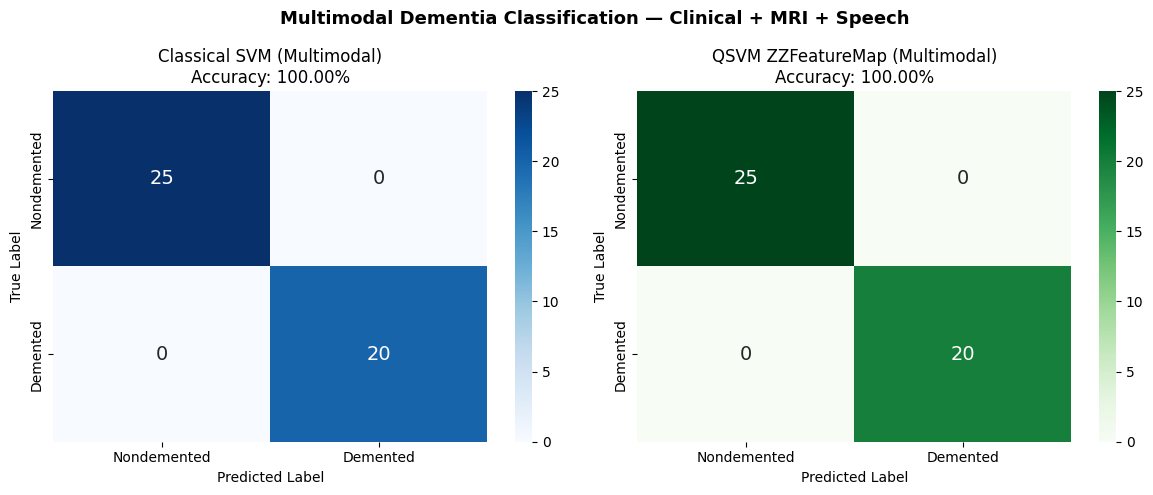

Saved: results/plots/multimodal_confusion_matrix.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title, cmap in zip(
    axes,
    [svm_pred, qsvm_pred],
    ['Classical SVM (Multimodal)', 'QSVM ZZFeatureMap (Multimodal)'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap=cmap,
                xticklabels=['Nondemented', 'Demented'],
                yticklabels=['Nondemented', 'Demented'],
                annot_kws={'size': 14})
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Multimodal Dementia Classification — Clinical + MRI + Speech',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/multimodal_confusion_matrix.png', dpi=150)
plt.show()
print('Saved: results/plots/multimodal_confusion_matrix.png')

In [10]:
# — Pickle the trained QSVM + scaler — train once, load instantly at demo time
with open('results/qsvm_model.pkl', 'wb') as f:
    pickle.dump(qsvm_clf, f)
print('✅ Saved: results/qsvm_model.pkl')

# The scaler is required to transform any new raw PCA features before prediction
with open('results/feature_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('✅ Saved: results/feature_scaler.pkl')

# — Verify pickle works —
with open('results/qsvm_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
verify_pred = loaded_model.predict(X_test)
assert accuracy_score(y_test, verify_pred) == qsvm_acc, 'Pickle verification failed!'
print('✅ Pickle verified — loaded model gives same accuracy')

# — Save results JSON (for Govind's viz notebook) —
final_results = {
    'dataset':              'multimodal_dementia_dataset.csv',
    'n_patients':           225,
    'n_features_total':     27,
    'n_features_per_mod':   {'clinical': 5, 'mri': 4, 'speech': 18},
    'pca_components':       2,
    'qsvm_feature_dim':     6,
    'svm_acc':              round(float(svm_acc), 4),
    'qsvm_acc':             round(float(qsvm_acc), 4),
    'published_baselines': {
        'akinrotimi_qsvm_base':         0.9125,
        'chakravarthi_classical_ref1':  0.9420,
        'so_et_al_clinical_ref7':       0.9720,
        'lin_washington_speech_ref6':   0.8400
    }
}

with open('results/multimodal_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print('\n✅ Saved: results/multimodal_results.json')
print(json.dumps(final_results, indent=2))

✅ Saved: results/qsvm_model.pkl
✅ Saved: results/feature_scaler.pkl


✅ Pickle verified — loaded model gives same accuracy

✅ Saved: results/multimodal_results.json
{
  "dataset": "multimodal_dementia_dataset.csv",
  "n_patients": 225,
  "n_features_total": 27,
  "n_features_per_mod": {
    "clinical": 5,
    "mri": 4,
    "speech": 18
  },
  "pca_components": 2,
  "qsvm_feature_dim": 6,
  "svm_acc": 1.0,
  "qsvm_acc": 1.0,
  "published_baselines": {
    "akinrotimi_qsvm_base": 0.9125,
    "chakravarthi_classical_ref1": 0.942,
    "so_et_al_clinical_ref7": 0.972,
    "lin_washington_speech_ref6": 0.84
  }
}
